# Decomposing colony dispersion with partial lineage information

This experiment asks:

> How much of the observed change in colony dispersion is attributable to spatial transport, and how much is attributable to the creation of new cells by division?

The [Tracking One-in-a-Million (TOIAM) dataset](https://zenodo.org/records/7260137) contains five one-minute time-lapse sequences of growing *Corynebacterium glutamicum* in Cell Tracking Challenge (CTC) format. We use the segmented configurations as untracked snapshots and reveal several configured percentages of complete division events. The withheld lineage is used for an oracle comparison.

Each segmented cell is replaced by one fixed-width Gaussian centered at its centroid:
$$
\bar\rho_k(x)=\sum_{a\in C_k}G_\sigma(x-c_{a,k}),
\qquad
\int_\Omega G_\sigma(x-c_{a,k})\,dx=1.
$$
Thus $\bar\rho_k$ is a spatial **cell-count measure**, not biomass. Elongation, rotation, and mask deformation do not become apparent transport.

We compare the following paths, all on the same grid and time window:

1. an unconstrained WFR geodesic at the fixed transport/source penalty scale $\delta=0.05$;
2. ACUOT with only the moment equality constraints and no lineage information;
3. one ACUOT geodesic per configured lineage percentage, using the moment constraints and its own source interval;
4. ACUOT with the same moment constraints and the exact full-lineage source observable, used as an oracle.

All methods use $\delta=0.05$, the same snapshots, moment constraints, and sampled lineage intervals. Density fidelity is reported for each method.


## Observable, decomposition, and affine information

For a density $\rho(t)$, define
$$
N(t)=\int_\Omega d\rho_t,\qquad
\mu(t)=\frac{1}{N(t)}\int_\Omega x\,d\rho_t,
$$
and the dispersion
$$
O(t)=\frac{1}{N(t)}\int_\Omega |x-\mu(t)|^2\,d\rho_t.
$$
With $q(t,x)=|x-\mu(t)|^2$, the centroid identity makes the integral of $\partial_t q$ vanish. The continuity equation then gives
$$
\frac{dO}{dt}=T(t)+S(t),
$$
where
$$
T(t)=\frac{1}{N(t)}\int_\Omega 2(x-\mu(t))\cdot d\omega_t,
\qquad
S(t)=\frac{1}{N(t)}\int_\Omega \bigl(q(t,x)-O(t)\bigr)\,d\zeta_t.
$$

At every observed node we retain the cell count, two first moments, and raw second moment. ACUOT constraints act on centered densities, so their equality targets are adjacent averages of the observed **raw moments**. Since the centered density is the average of two neighboring staggered densities and the first endpoint is fixed, these equalities recursively encode every observed node moment.

For interval $k$, partial lineage supplies a finite-population interval
$$
\ell_k\le
\int_\Omega
\frac{q_k(x)-O_k}{N_k}\,d\zeta_k(x)
\le u_k.
$$
The experiment assumes binary division, no death or field-of-view entry/exit in the selected window, and uniform sampling of complete parent-division events.

In [1]:
from collections import defaultdict
from pathlib import Path
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.stats import t as student_t


def env_flag(name, default=False):
    value = os.environ.get(name)
    if value is None:
        return bool(default)
    return value.strip().lower() in {"1", "true", "yes", "on"}


def env_path(name):
    value = os.environ.get(name)
    return Path(value).expanduser().resolve() if value else None


def print_table(rows, columns=None, digits=4):
    if not rows:
        print("(no rows)")
        return
    columns = list(columns or rows[0].keys())

    def format_value(value):
        if isinstance(value, (float, np.floating)):
            return f"{float(value):.{digits}g}"
        return str(value)

    formatted = [
        [format_value(row.get(column, "")) for column in columns]
        for row in rows
    ]
    widths = [
        max(len(column), *(len(row[j]) for row in formatted))
        for j, column in enumerate(columns)
    ]
    print(" | ".join(column.ljust(width) for column, width in zip(columns, widths)))
    print("-+-".join("-" * width for width in widths))
    for row in formatted:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


# Import the local package when launched from either the repository root or paper/.
_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in (_cwd, _cwd.parent)
        if (candidate / "src" / "acuot").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from the ACUOT repository root or paper/ directory.")
sys.path.insert(0, str(REPO_ROOT / "src"))

from acuot import computeGeodesic

sys.path.insert(0, str(REPO_ROOT / "paper"))
from toiam_figures import (
    DELTA, TEXTWIDTH_PT, TEXTHEIGHT_PT, PAPERWIDTH_PT, PAPERHEIGHT_PT,
    TEX_POINTS_PER_INCH, FIGURE_WIDTH_IN, MAX_FIGURE_HEIGHT_IN,
    save_manuscript_pdf,
)


# Data and window. TOIAM_ROOT must contain directories such as 00_GT/TRA.
TOIAM_ROOT = env_path("TOIAM_ROOT") or (REPO_ROOT / "paper" / "input" / "toiam")
SEGMENTATION_DIR_OVERRIDE = env_path("TOIAM_SEG_DIR")
TRACKING_DIR_OVERRIDE = env_path("TOIAM_TRACK_DIR")
SEQUENCE = os.environ.get("TOIAM_SEQUENCE", "00")

FRAME_START = int(os.environ.get("TOIAM_FRAME_START", "200"))
FRAME_STOP = int(os.environ.get("TOIAM_FRAME_STOP", "600"))
FRAME_STRIDE = int(os.environ.get("TOIAM_FRAME_STRIDE", "25"))
FRAME_DT_MINUTES = float(os.environ.get("TOIAM_FRAME_DT_MINUTES", "1.0"))
PIXEL_SIZE_UM = float(os.environ.get("TOIAM_PIXEL_SIZE_UM", "0.072"))

# Spatial representation and partial-lineage experiment.
GRID_LONG_SIDE = int(os.environ.get("TOIAM_GRID_LONG_SIDE", "32"))
SIGMA_GRID_CELLS = float(os.environ.get("TOIAM_SIGMA_GRID_CELLS", "1.0"))
LINEAGE_PERCENTAGES = [
    float(value.strip())
    for value in os.environ.get(
        "TOIAM_LINEAGE_PERCENTAGES", "30,50,80"
    ).split(",")
    if value.strip()
]
SEED = int(os.environ.get("TOIAM_SEED", "58"))

# The transport/source penalty is fixed at DELTA = 0.05.
PPXA_ITERATIONS = int(os.environ.get("TOIAM_PPXA_ITERATIONS", "50000"))
PPXA_ALPHA = float(os.environ.get("TOIAM_PPXA_ALPHA", "1.8"))
VERBOSE_SOLVER = env_flag("TOIAM_VERBOSE_SOLVER", True)

if FRAME_STOP <= FRAME_START or FRAME_STRIDE <= 0:
    raise ValueError("Require FRAME_STOP > FRAME_START and FRAME_STRIDE > 0.")
if (FRAME_STOP - FRAME_START) % FRAME_STRIDE:
    raise ValueError("FRAME_STOP - FRAME_START must be divisible by FRAME_STRIDE.")
if not LINEAGE_PERCENTAGES:
    raise ValueError("LINEAGE_PERCENTAGES must contain at least one percentage.")
if not np.all(np.isfinite(LINEAGE_PERCENTAGES)) or any(
    percentage < 0 or percentage > 100
    for percentage in LINEAGE_PERCENTAGES
):
    raise ValueError("Every lineage percentage must lie in [0, 100].")
if len(set(LINEAGE_PERCENTAGES)) != len(LINEAGE_PERCENTAGES):
    raise ValueError("LINEAGE_PERCENTAGES must not contain duplicates.")
if GRID_LONG_SIDE < 8 or SIGMA_GRID_CELLS <= 0:
    raise ValueError("The solver grid and Gaussian bandwidth must be positive.")
if PPXA_ITERATIONS < 100:
    raise ValueError("PPXA_ITERATIONS must be at least 100 for this solver.")
print(f"TOIAM root: {TOIAM_ROOT}")
print(
    f"sequence={SEQUENCE}, frames={FRAME_START}:{FRAME_STOP}:{FRAME_STRIDE}, "
    f"lineage percentages={LINEAGE_PERCENTAGES}, iterations={PPXA_ITERATIONS}"
)
print(f"experiment delta: {DELTA:g}")

TOIAM root: C:\Users\mao17\Workspace\acuot\paper\input\toiam
sequence=00, frames=200:600:25, lineage percentages=[30.0, 50.0, 80.0], iterations=50000
experiment delta: 0.05


## Load and validate a division-only window

The notebook expects an already extracted CTC archive; it does not download or cache the 2.2 GB dataset. The tracking directory contains the lineage table and masks whose positive labels are track IDs. For observed snapshots, the loader first looks for a dense relabeled segmentation directory and otherwise uses the tracking masks while immediately discarding their IDs.

A CTC lineage row is $(L,B,E,P)$: track label, inclusive begin frame, inclusive end frame, and parent label. A binary division is one parent event with exactly two daughters beginning at $E+1$. The checks below reject parentless entries, deaths, exits, incomplete divisions, and disagreement between cell-count increase and the number of complete division events.

In [2]:
FRAME_RE = re.compile(r"(\d+)(?=\.tiff?$)", flags=re.IGNORECASE)


def index_tiffs(directory):
    directory = Path(directory)
    files = {}
    if not directory.is_dir():
        return files
    for path in directory.iterdir():
        if not path.is_file() or path.suffix.lower() not in {".tif", ".tiff"}:
            continue
        match = FRAME_RE.search(path.name)
        if match is None:
            continue
        frame = int(match.group(1))
        if frame in files:
            raise ValueError(f"Duplicate TIFF for frame {frame} in {directory}")
        files[frame] = path
    return files


def centroids_px_by_label(path):
    with Image.open(path) as image:
        if getattr(image, "n_frames", 1) != 1:
            raise ValueError(f"Expected a single-page 2-D label TIFF: {path}")
        mask = np.array(image)

    if mask.ndim != 2 or not np.issubdtype(mask.dtype, np.integer):
        raise ValueError(f"Expected a 2-D integer label mask: {path}")
    if np.any(mask < 0):
        raise ValueError(f"Negative labels in {path}")

    rows, cols = np.nonzero(mask)
    if rows.size == 0:
        raise ValueError(f"No positive labels in {path}")

    labels = mask[rows, cols].astype(np.int64, copy=False)
    ids, inverse = np.unique(labels, return_inverse=True)
    counts = np.bincount(inverse)
    y = np.bincount(inverse, weights=rows + 0.5) / counts
    x = np.bincount(inverse, weights=cols + 0.5) / counts
    points = np.column_stack((y, x))
    return mask.shape, {int(label): point for label, point in zip(ids, points)}


def read_tracks(path):
    tracks = {}
    for line_number, text in enumerate(
        Path(path).read_text(encoding="utf-8").splitlines(), start=1
    ):
        text = text.strip()
        if not text:
            continue
        fields = text.split()
        if len(fields) != 4:
            raise ValueError(f"{path}:{line_number}: expected four integers")
        try:
            label, begin, end, parent = map(int, fields)
        except ValueError as error:
            raise ValueError(f"{path}:{line_number}: expected four integers") from error
        if label <= 0 or begin < 0 or end < begin or parent < 0:
            raise ValueError(f"{path}:{line_number}: invalid track row")
        if label in tracks:
            raise ValueError(f"Duplicate track label {label}")
        tracks[label] = (begin, end, parent)

    if not tracks:
        raise ValueError(f"No tracks in {path}")
    for label, (_, _, parent) in tracks.items():
        if parent == label:
            raise ValueError(f"Track {label} is its own parent")
        if parent and parent not in tracks:
            raise ValueError(f"Track {label} has unknown parent {parent}")
    return tracks


def binary_divisions_in_window(tracks, start, stop):
    children = defaultdict(list)
    for label, (_, _, parent) in tracks.items():
        if parent:
            children[parent].append(label)

    entries = [
        label
        for label, (begin, _, parent) in tracks.items()
        if parent == 0 and start < begin <= stop
    ]
    if entries:
        raise ValueError(
            "The selected window contains parentless entries; "
            f"first labels: {entries[:5]}"
        )

    events = []
    for parent, (_, end, _) in tracks.items():
        if not (start <= end < stop):
            continue
        daughters = sorted(children.get(parent, ()))
        birth = end + 1
        if len(daughters) != 2:
            raise ValueError(
                f"Track {parent} ends at {end} inside the window but has "
                f"{len(daughters)} daughters (death, exit, or incomplete division)."
            )
        if any(tracks[daughter][0] != birth for daughter in daughters):
            raise ValueError(
                f"Daughters of track {parent} do not both begin at frame {birth}."
            )
        events.append(
            {"birth": birth, "parent": parent, "daughters": tuple(daughters)}
        )
    return sorted(events, key=lambda event: (event["birth"], event["parent"]))

In [3]:
node_frames = np.arange(FRAME_START, FRAME_STOP + 1, FRAME_STRIDE, dtype=int)
if node_frames.size < 3 or node_frames[-1] != FRAME_STOP:
    raise ValueError("Choose at least three equally spaced observed node frames.")

tracking_dir = (
    TRACKING_DIR_OVERRIDE
    if TRACKING_DIR_OVERRIDE is not None
    else TOIAM_ROOT / f"{SEQUENCE}_GT" / "TRA"
)
lineage_path = tracking_dir / "man_track.txt"
if not lineage_path.is_file():
    raise FileNotFoundError(
        f"Missing {lineage_path}. Set TOIAM_ROOT to the extracted CTC directory "
        "or set TOIAM_TRACK_DIR explicitly."
    )

tracking_files = index_tiffs(tracking_dir)
if not tracking_files:
    raise FileNotFoundError(f"No tracking TIFFs found in {tracking_dir}.")

segmentation_candidates = []
if SEGMENTATION_DIR_OVERRIDE is not None:
    segmentation_candidates.append(SEGMENTATION_DIR_OVERRIDE)
segmentation_candidates.extend(
    [
        TOIAM_ROOT / f"{SEQUENCE}_ERR_SEG",
        TOIAM_ROOT / f"{SEQUENCE}_ST" / "SEG",
        tracking_dir,
    ]
)

segmentation_dir = None
segmentation_files = None
required_nodes = set(node_frames.tolist())
for candidate in segmentation_candidates:
    candidate_files = index_tiffs(candidate)
    if required_nodes.issubset(candidate_files):
        segmentation_dir = candidate
        segmentation_files = candidate_files
        break
if segmentation_dir is None:
    checked = ", ".join(str(path) for path in segmentation_candidates)
    raise FileNotFoundError(
        "No candidate segmentation directory contains every selected node frame. "
        f"Checked: {checked}. Set TOIAM_SEG_DIR or adjust the configured window."
    )

tracks = read_tracks(lineage_path)
events = binary_divisions_in_window(tracks, FRAME_START, FRAME_STOP)
events_by_interval = [
    [
        event
        for event in events
        if left < event["birth"] <= right
    ]
    for left, right in zip(node_frames[:-1], node_frames[1:])
]

# Load only selected snapshot masks.
observed_centroids_px = []
image_shape = None
for frame in node_frames:
    shape, labeled_points = centroids_px_by_label(segmentation_files[int(frame)])
    if image_shape is None:
        image_shape = shape
    elif shape != image_shape:
        raise ValueError(f"Segmentation shape changed at frame {frame}: {shape}")
    observed_centroids_px.append(np.vstack(list(labeled_points.values())))

# Load tracking masks lazily at actual daughter birth frames.
tracking_centroid_cache = {}
for event in events:
    birth = event["birth"]
    if birth not in tracking_files:
        raise FileNotFoundError(
            f"Missing tracking mask for daughter birth frame {birth}."
        )
    if birth not in tracking_centroid_cache:
        shape, labeled_points = centroids_px_by_label(tracking_files[birth])
        if shape != image_shape:
            raise ValueError(
                f"Tracking and segmentation shapes disagree at frame {birth}."
            )
        active_labels = {
            label
            for label, (begin, end, _) in tracks.items()
            if begin <= birth <= end
        }
        mask_labels = set(labeled_points)
        if mask_labels != active_labels:
            raise ValueError(
                f"Tracking mask/table mismatch at frame {birth}; "
                f"missing={sorted(active_labels - mask_labels)[:5]}, "
                f"extra={sorted(mask_labels - active_labels)[:5]}"
            )
        tracking_centroid_cache[birth] = labeled_points

    labeled_points = tracking_centroid_cache[birth]
    missing_daughters = [
        daughter for daughter in event["daughters"] if daughter not in labeled_points
    ]
    if missing_daughters:
        raise ValueError(
            f"Missing daughter labels {missing_daughters} at frame {birth}."
        )
    event["daughter_centroids_px"] = np.vstack(
        [labeled_points[daughter] for daughter in event["daughters"]]
    )

cell_counts = np.array([len(points) for points in observed_centroids_px], dtype=int)
division_counts = np.array([len(bin_events) for bin_events in events_by_interval])
count_increases = np.diff(cell_counts)
if np.any(count_increases < 0) or not np.array_equal(
    count_increases, division_counts
):
    raise ValueError(
        "Cell-count increases do not equal complete binary divisions in every "
        "selected interval. Choose a different no-entry/no-exit window."
    )

audit_rows = [
    {
        "left_frame": int(node_frames[k]),
        "right_frame": int(node_frames[k + 1]),
        "N_left": int(cell_counts[k]),
        "N_right": int(cell_counts[k + 1]),
        "D_count": int(count_increases[k]),
        "D_lineage": int(division_counts[k]),
    }
    for k in range(len(node_frames) - 1)
]
print(f"Snapshot masks: {segmentation_dir}")
print(f"Tracking data: {tracking_dir}")
print(f"Image shape: {image_shape}; complete divisions: {division_counts.sum()}")
print_table(audit_rows)

Snapshot masks: C:\Users\mao17\Workspace\acuot\paper\input\toiam\00_GT\TRA
Tracking data: C:\Users\mao17\Workspace\acuot\paper\input\toiam\00_GT\TRA
Image shape: (1094, 938); complete divisions: 387
left_frame | right_frame | N_left | N_right | D_count | D_lineage
-----------+-------------+--------+---------+---------+----------
200        | 225         | 9      | 14      | 5       | 5        
225        | 250         | 14     | 16      | 2       | 2        
250        | 275         | 16     | 19      | 3       | 3        
275        | 300         | 19     | 27      | 8       | 8        
300        | 325         | 27     | 31      | 4       | 4        
325        | 350         | 31     | 37      | 6       | 6        
350        | 375         | 37     | 51      | 14      | 14       
375        | 400         | 51     | 58      | 7       | 7        
400        | 425         | 58     | 75      | 17      | 17       
425        | 450         | 75     | 98      | 23      | 23       
450      

## Centroid-Gaussian observations and centered raw moments

Coordinates are scaled by the longer image side, preserving aspect ratio. The solver grid follows that aspect ratio, and each Gaussian is normalized by the same rectangular quadrature used by ACUOT. The bandwidth is fixed at a configured number of solver cells; it is not tuned.

The four density constraints use centered targets
$$
M^c_k=\tfrac12(M_k+M_{k+1})
$$
for mass, both first moments, and the raw second moment. The centered centroid and dispersion are derived from those raw targets rather than by averaging node centroids or node dispersions.

In [4]:
height_px, width_px = image_shape
long_side_px = max(height_px, width_px)
LY = height_px / long_side_px
LX = width_px / long_side_px

if height_px >= width_px:
    NY = GRID_LONG_SIDE
    NX = max(8, int(round(GRID_LONG_SIDE * width_px / height_px)))
else:
    NX = GRID_LONG_SIDE
    NY = max(8, int(round(GRID_LONG_SIDE * height_px / width_px)))

DY = LY / NY
DX = LX / NX
CELL_AREA = DY * DX
y_coords = (np.arange(NY) + 0.5) * DY
x_coords = (np.arange(NX) + 0.5) * DX
Y, X = np.meshgrid(y_coords, x_coords, indexing="ij")
SIGMA = SIGMA_GRID_CELLS * max(DY, DX)


def normalize_points(points_px):
    return np.asarray(points_px, dtype=float) / long_side_px


def centroids_to_density(points, chunk_size=256):
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != 2 or points.shape[0] == 0:
        raise ValueError("Expected a nonempty array of (y, x) centroids.")
    density = np.zeros((NY, NX), dtype=float)
    for first in range(0, len(points), chunk_size):
        chunk = points[first : first + chunk_size]
        squared_distance = (
            (Y[None, :, :] - chunk[:, 0, None, None]) ** 2
            + (X[None, :, :] - chunk[:, 1, None, None]) ** 2
        )
        kernels = np.exp(-0.5 * squared_distance / SIGMA**2)
        normalizers = kernels.sum(axis=(1, 2)) * CELL_AREA
        if np.any(normalizers <= 0) or not np.all(np.isfinite(normalizers)):
            raise FloatingPointError("A Gaussian kernel could not be normalized.")
        density += (kernels / normalizers[:, None, None]).sum(axis=0)
    return density


def raw_moments(densities):
    densities = np.asarray(densities)
    mass = densities.sum(axis=(1, 2)) * CELL_AREA
    first_y = (densities * Y).sum(axis=(1, 2)) * CELL_AREA
    first_x = (densities * X).sum(axis=(1, 2)) * CELL_AREA
    raw_second = (densities * (Y**2 + X**2)).sum(axis=(1, 2)) * CELL_AREA
    return mass, first_y, first_x, raw_second


observed_centroids = [
    normalize_points(points_px) for points_px in observed_centroids_px
]
observed_density = np.stack(
    [centroids_to_density(points) for points in observed_centroids],
    axis=0,
)

N_node, P_y_node, P_x_node, R_node = raw_moments(observed_density)
np.testing.assert_allclose(N_node, cell_counts, rtol=1e-11, atol=1e-9)

mu_y_node = P_y_node / N_node
mu_x_node = P_x_node / N_node
O_node = R_node / N_node - mu_y_node**2 - mu_x_node**2
if np.any(O_node < -1e-12):
    raise FloatingPointError("Observed dispersion is numerically negative.")
O_node = np.maximum(O_node, 0)

N_mid = 0.5 * (N_node[:-1] + N_node[1:])
P_y_mid = 0.5 * (P_y_node[:-1] + P_y_node[1:])
P_x_mid = 0.5 * (P_x_node[:-1] + P_x_node[1:])
R_mid = 0.5 * (R_node[:-1] + R_node[1:])
mu_y_mid = P_y_mid / N_mid
mu_x_mid = P_x_mid / N_mid
O_mid = R_mid / N_mid - mu_y_mid**2 - mu_x_mid**2
q_mid = (
    (Y[None, :, :] - mu_y_mid[:, None, None]) ** 2
    + (X[None, :, :] - mu_x_mid[:, None, None]) ** 2
)

T_STEPS = len(node_frames) - 1
DT = FRAME_STRIDE * FRAME_DT_MINUTES
LL = (T_STEPS * DT, LY, LX)

print(
    f"Solver grid: {NY} x {NX}; domain: {LY:.4g} x {LX:.4g}; "
    f"sigma={SIGMA:.4g}; dt={DT:g} min"
)
print(
    f"Physical image size: {height_px * PIXEL_SIZE_UM:.3g} x "
    f"{width_px * PIXEL_SIZE_UM:.3g} micrometers"
)
print(f"Maximum cell-mass error: {np.max(np.abs(N_node - cell_counts)):.3e}")

Solver grid: 32 x 27; domain: 1 x 0.8574; sigma=0.03176; dt=25 min
Physical image size: 78.8 x 67.5 micrometers
Maximum cell-mass error: 2.842e-14


## Partial-lineage source interval

A complete division event contributes the net new unit
$$
\eta_{e,k}=\tfrac12G_\sigma(\cdot-c_{d_1})+
           \tfrac12G_\sigma(\cdot-c_{d_2}),
$$
evaluated at the daughters' actual birth frame. Its centered source-observable contribution is
$$
Y_{e,k}=\int_\Omega
\frac{q_k(x)-O_k}{N_k}\,d\eta_{e,k}(x).
$$

For each configured percentage $p$, reveal $n_k=\lceil pD_k/100\rceil$ of the $D_k$ complete events in an interval of length $\Delta t$, uniformly without replacement. A single seeded ordering is used in each interval, so lower-percentage samples are nested within higher-percentage samples. The estimate and finite-population standard error are
$$
\widehat S_k=\frac{D_k}{\Delta t}\bar Y_k,\qquad
\widehat{\mathrm{SE}}(\widehat S_k)=
\frac{D_k}{\Delta t}
\sqrt{\left(1-\frac{n_k}{D_k}\right)\frac{s_k^2}{n_k}}.
$$
For $n_k\ge2$, a $95\%$ Student interval supplies $[\ell_k,u_k]$. Zero-division intervals and complete reveal give point constraints. At $0\%$ the source block is omitted entirely. When exactly one event is revealed, the Student interval is undefined, so the unrevealed events receive conservative bounds from the known minimum and maximum of the spatial source kernel.

In [5]:
source_kernel = (
    q_mid - O_mid[:, None, None]
) / N_mid[:, None, None]

source_full = np.zeros(T_STEPS)
event_contributions = []

for k, bin_events in enumerate(events_by_interval):
    values = []
    for event in bin_events:
        daughter_points = normalize_points(event["daughter_centroids_px"])
        # centroids_to_density has mass 2 here; multiplying by 1/2 gives net mass 1.
        eta = 0.5 * centroids_to_density(daughter_points)
        value = (
            (source_kernel[k] * eta).sum() * CELL_AREA
        )
        values.append(value)

    values = np.asarray(values, dtype=float)
    event_contributions.append(values)
    if len(values):
        source_full[k] = values.sum() / DT

# One seeded ordering per interval makes all configured reveals nested: a smaller
# percentage always uses a prefix of the events available to a larger percentage.
rng = np.random.default_rng(SEED)
event_orders = [rng.permutation(len(values)) for values in event_contributions]
lineage_intervals = {}

for percentage in LINEAGE_PERCENTAGES:
    revealed_counts = np.zeros(T_STEPS, dtype=int)
    source_estimate = np.zeros(T_STEPS)
    source_lower = np.zeros(T_STEPS)
    source_upper = np.zeros(T_STEPS)
    interval_method = np.full(T_STEPS, "zero-division point", dtype=object)

    for k, values in enumerate(event_contributions):
        D_k = len(values)
        if D_k == 0:
            continue

        n_k = min(int(np.ceil((percentage / 100.0) * D_k)), D_k)
        revealed_counts[k] = n_k
        if n_k == 0:
            source_estimate[k] = np.nan
            source_lower[k] = np.nan
            source_upper[k] = np.nan
            interval_method[k] = "no source constraint"
            continue

        sample = values[event_orders[k][:n_k]]
        sample_mean = sample.mean()
        source_estimate[k] = (D_k / DT) * sample_mean

        if n_k == D_k:
            source_estimate[k] = source_full[k]
            source_lower[k] = source_full[k]
            source_upper[k] = source_full[k]
            interval_method[k] = "complete-reveal point"
        elif n_k == 1:
            # A Student interval is undefined for one sample. Every unit-mass
            # event contribution lies between the extrema of source_kernel[k],
            # so bound the unrevealed events by that known spatial support.
            source_lower[k] = (
                sample.sum() + (D_k - n_k) * source_kernel[k].min()
            ) / DT
            source_upper[k] = (
                sample.sum() + (D_k - n_k) * source_kernel[k].max()
            ) / DT
            interval_method[k] = "one-sample support"
        else:
            sample_variance = sample.var(ddof=1)
            standard_error = (D_k / DT) * np.sqrt(
                (1.0 - n_k / D_k) * sample_variance / n_k
            )
            critical_value = student_t.ppf(0.975, df=n_k - 1)
            source_lower[k] = (
                source_estimate[k] - critical_value * standard_error
            )
            source_upper[k] = (
                source_estimate[k] + critical_value * standard_error
            )
            interval_method[k] = "finite-population t"

    lineage_intervals[percentage] = {
        "revealed_counts": revealed_counts,
        "estimate": source_estimate,
        "lower": source_lower,
        "upper": source_upper,
        "method": interval_method,
    }

interval_rows = []
for percentage, interval in lineage_intervals.items():
    for k, audit_row in enumerate(audit_rows):
        D_k = int(audit_row["D_lineage"])
        n_k = int(interval["revealed_counts"][k])
        interval_rows.append(
            {
                "lineage_pct": percentage,
                "left_frame": audit_row["left_frame"],
                "right_frame": audit_row["right_frame"],
                "D_lineage": D_k,
                "n_revealed": n_k,
                "effective_pct": 0.0 if D_k == 0 else 100.0 * n_k / D_k,
                "interval": interval["method"][k],
                "S_estimate": interval["estimate"][k],
                "S_lower": interval["lower"][k],
                "S_upper": interval["upper"][k],
                "S_full": source_full[k],
            }
        )
print_table(
    interval_rows,
    columns=[
        "lineage_pct", "left_frame", "right_frame", "D_lineage",
        "n_revealed", "effective_pct", "interval", "S_estimate",
        "S_lower", "S_upper", "S_full",
    ],
)

lineage_pct | left_frame | right_frame | D_lineage | n_revealed | effective_pct | interval              | S_estimate | S_lower    | S_upper    | S_full    
------------+------------+-------------+-----------+------------+---------------+-----------------------+------------+------------+------------+-----------
30          | 200        | 225         | 5         | 2          | 40            | finite-population t   | 2.398e-07  | -4.922e-05 | 4.97e-05   | 1.015e-06 
30          | 225        | 250         | 2         | 1          | 50            | one-sample support    | -5.31e-06  | -1.112e-05 | 0.00148    | -3.911e-06
30          | 250        | 275         | 3         | 1          | 33.33         | one-sample support    | 1.282e-05  | -1.182e-05 | 0.002531   | 8.423e-06 
30          | 275        | 300         | 8         | 3          | 37.5          | finite-population t   | -9.299e-06 | -1.607e-05 | -2.524e-06 | -6.803e-07
30          | 300        | 325         | 4         | 2          

## Constraint assembly and experiment at $\delta=0.05$

For two spatial dimensions, each ACUOT block has
$$
[H_\rho,H_{\omega_y},H_{\omega_x},H_\zeta]
$$
with shape $(T,N_y,N_x)$. The no-lineage solve uses only four equality blocks: mass, $y$-first moment, $x$-first moment, and raw second moment. Each positive lineage percentage adds a fifth block using its own source-observable interval.

At $\delta=0.05$, we compute unconstrained WFR, no-lineage ACUOT, each configured lineage-percentage ACUOT, and the full-lineage oracle. The density-fidelity metric compares the staggered node densities with every interior observed centroid-Gaussian snapshot:
$$
\mathcal L(\delta)=
\sqrt{\frac{1}{T-1}\sum_{k=1}^{T-1}
\int_\Omega |\rho^\delta_k-\bar\rho_k|^2\,dx}.
$$
Endpoints are excluded because all runs match them by construction. The WFR solution is retained as the baseline. This metric is descriptive.

In [6]:
def repeated(field):
    return np.broadcast_to(np.asarray(field, dtype=float), (T_STEPS, NY, NX)).copy()


zeros = np.zeros((T_STEPS, NY, NX), dtype=float)
ones = np.ones((T_STEPS, NY, NX), dtype=float)
Y_field = repeated(Y)
X_field = repeated(X)
R_field = repeated(Y**2 + X**2)

H_moments = [
    [ones, zeros.copy(), zeros.copy(), zeros.copy()],
    [Y_field, zeros.copy(), zeros.copy(), zeros.copy()],
    [X_field, zeros.copy(), zeros.copy(), zeros.copy()],
    [R_field, zeros.copy(), zeros.copy(), zeros.copy()],
]
H_source = [zeros.copy(), zeros.copy(), zeros.copy(), source_kernel.copy()]
H_lineage = [*H_moments, H_source]

moment_targets = [
    N_mid.copy(),
    P_y_mid.copy(),
    P_x_mid.copy(),
    R_mid.copy(),
]
GL_moments = [target.copy() for target in moment_targets]
GU_moments = [target.copy() for target in moment_targets]
GL_full = [target.copy() for target in moment_targets] + [source_full.copy()]
GU_full = [bound.copy() for bound in GL_full]
configured_constraints = {}
for percentage, interval in lineage_intervals.items():
    if percentage == 0:
        blocks = H_moments
        lower = [bound.copy() for bound in GL_moments]
        upper = [bound.copy() for bound in GU_moments]
    elif percentage == 100:
        blocks = H_lineage
        lower = [bound.copy() for bound in GL_full]
        upper = [bound.copy() for bound in GU_full]
    else:
        blocks = H_lineage
        lower = [target.copy() for target in moment_targets] + [
            interval["lower"].copy()
        ]
        upper = [target.copy() for target in moment_targets] + [
            interval["upper"].copy()
        ]
    configured_constraints[percentage] = (blocks, lower, upper)

for block in H_lineage:
    if len(block) != 4 or any(array.shape != (T_STEPS, NY, NX) for array in block):
        raise AssertionError("Every 2-D constraint block must contain four centered arrays.")
constraint_sets = [
    ("moment-only", H_moments, GL_moments, GU_moments),
    *(
        (f"{percentage:g}% lineage", *constraint_spec)
        for percentage, constraint_spec in configured_constraints.items()
    ),
    ("full-lineage", H_lineage, GL_full, GU_full),
]
for name, blocks, lower, upper in constraint_sets:
    if not (len(blocks) == len(lower) == len(upper)):
        raise AssertionError(f"Mismatched constraint counts for {name}.")
    if any(bound.shape != (T_STEPS,) for bound in (*lower, *upper)):
        raise AssertionError(f"Every {name} bound must be a length-T array.")

print(
    f"Constraint blocks assembled for {len(configured_constraints)} configured "
    "lineage percentages."
)

Constraint blocks assembled for 3 configured lineage percentages.


In [7]:
def trajectory_l2(solution):
    predicted = np.asarray(solution.U.D[0])
    if predicted.shape != observed_density.shape:
        raise ValueError(
            f"Predicted trajectory has shape {predicted.shape}, "
            f"expected {observed_density.shape}."
        )
    difference = predicted[1:-1] - observed_density[1:-1]
    squared_l2 = (
        (difference**2).sum(axis=(1, 2)) * CELL_AREA
    )
    loss = float(np.sqrt(squared_l2.mean()))
    observed_scale = float(
        np.sqrt(
            (
                (observed_density[1:-1] ** 2).sum(axis=(1, 2))
                * CELL_AREA
            ).mean()
        )
    )
    return loss, loss / observed_scale


print(f"Solving WFR at delta={DELTA:g}...")
wfr_solution, wfr_history = computeGeodesic(
    observed_density[0],
    observed_density[-1],
    T_STEPS,
    LL,
    p=2.0,
    q=2.0,
    delta=DELTA,
    niter=PPXA_ITERATIONS,
    alpha=PPXA_ALPHA,
    verbose=False,
)


WFR_DELTA = DELTA
print(f"Retained the WFR baseline at delta={DELTA:g}.")

Solving WFR at delta=0.05...
Retained the WFR baseline at delta=0.05.


In [8]:
if globals().get("WFR_DELTA") != DELTA:
    raise RuntimeError("Run the WFR cell at delta=0.05 first.")

print(f"\nRunning ACUOT experiments at delta={DELTA:g}...")
print("Solving no-lineage moment-only ACUOT...")
no_lineage_solution, no_lineage_history = computeGeodesic(
    observed_density[0],
    observed_density[-1],
    T_STEPS,
    LL,
    H=H_moments,
    GL=GL_moments,
    GU=GU_moments,
    p=2.0,
    q=2.0,
    delta=DELTA,
    niter=PPXA_ITERATIONS,
    alpha=PPXA_ALPHA,
    verbose=VERBOSE_SOLVER,
)

configured_solutions = {}
for percentage, (blocks, lower, upper) in configured_constraints.items():
    if percentage == 0:
        print("0% lineage reuses the no-lineage geodesic.")
        configured_solutions[percentage] = (
            no_lineage_solution, no_lineage_history, blocks, lower, upper
        )
        continue

    print(f"Solving {percentage:g}% lineage ACUOT...")
    solution, history = computeGeodesic(
        observed_density[0],
        observed_density[-1],
        T_STEPS,
        LL,
        H=blocks,
        GL=lower,
        GU=upper,
        p=2.0,
        q=2.0,
        delta=DELTA,
        niter=PPXA_ITERATIONS,
        alpha=PPXA_ALPHA,
        verbose=VERBOSE_SOLVER,
    )
    configured_solutions[percentage] = (
        solution, history, blocks, lower, upper
    )

if 100 in configured_solutions:
    full_solution, full_history = configured_solutions[100][:2]
    print("100% lineage also serves as the full-lineage oracle.")
else:
    print("Solving full-lineage scalar-oracle ACUOT...")
    full_solution, full_history = computeGeodesic(
        observed_density[0],
        observed_density[-1],
        T_STEPS,
        LL,
        H=H_lineage,
        GL=GL_full,
        GU=GU_full,
        p=2.0,
        q=2.0,
        delta=DELTA,
        niter=PPXA_ITERATIONS,
        alpha=PPXA_ALPHA,
        verbose=VERBOSE_SOLVER,
    )

method_data = {
    "WFR": (wfr_solution, wfr_history, None, None, None),
    "No-lineage ACUOT": (
        no_lineage_solution,
        no_lineage_history,
        H_moments,
        GL_moments,
        GU_moments,
    ),
}
for percentage, result in configured_solutions.items():
    if percentage not in (0, 100):
        method_data[f"{percentage:g}% lineage ACUOT"] = result
method_data["Full-lineage ACUOT"] = (
    full_solution,
    full_history,
    H_lineage,
    GL_full,
    GU_full,
)


RESULTS_DELTA = DELTA
print(f"Completed all {len(method_data)} methods at delta={DELTA:g}.")


Running ACUOT experiments at delta=0.05...
Solving no-lineage moment-only ACUOT...
Computing a geodesic for optimal transport with source and constraint... (including inequality constraints)
Progress: 99%
Done.
Solving 30% lineage ACUOT...
Computing a geodesic for optimal transport with source and constraint... (including inequality constraints)
Progress: 99%
Done.
Solving 50% lineage ACUOT...
Computing a geodesic for optimal transport with source and constraint... (including inequality constraints)
Progress: 99%
Done.
Solving 80% lineage ACUOT...
Computing a geodesic for optimal transport with source and constraint... (including inequality constraints)
Progress: 99%
Done.
Solving full-lineage scalar-oracle ACUOT...
Computing a geodesic for optimal transport with source and constraint... (including inequality constraints)
Progress: 99%
Done.
Completed all 6 methods at delta=0.05.


## Evaluation

At $\delta=0.05$, WFR, no-lineage ACUOT, every configured lineage-percentage ACUOT, and the full-lineage oracle are evaluated with the same observed centered $q_k,N_k,O_k$. This makes their reported $T_k$ and $S_k$ comparable to the decomposition of the observed dispersion curve even though unconstrained WFR need not reproduce that curve.

The withheld-lineage reference is
$$
S_k^{\mathrm{ref}}=S_k^{\mathrm{full}},
\qquad
T_k^{\mathrm{ref}}=
\frac{O_{k+1}-O_k}{\Delta t}-S_k^{\mathrm{full}}.
$$
The latter is the minimal closure-based transport reference; it avoids adding a second cell-level transport convention.

Because normalized dispersion does not have an exact finite-step midpoint chain rule when mass and centroid change, $T_k+S_k-\Delta O_k/\Delta t$ is reported as a discretization/closure diagnostic rather than asserted to be zero. The full-lineage ACUOT solve fixes only the scalar source observable, not the complete source field.

One summary table and diagnostic figure compare all methods at $\delta=0.05$.


Configured lineage-interval coverage:
lineage_pct | coverage | events_revealed | events_total
------------+----------+-----------------+-------------
30          | 0.9375   | 124             | 387         
50          | 1        | 197             | 387         
80          | 0.9375   | 316             | 387         

Results for delta=0.05
method             | density_L2 | relative_density_L2 | T_MAE     | T_RMSE    | S_MAE     | S_RMSE    | closure_RMSE | final_CE_L2 | iter_CE_L2 | iter_interp_L2 | endpoint_L2_max | node_moment_error | moment_violation | source_violation | minimum_density
-------------------+------------+---------------------+-----------+-----------+-----------+-----------+--------------+-------------+------------+----------------+-----------------+-------------------+------------------+------------------+----------------
WFR                | 391.6      | 1.057               | 0.0001424 | 0.0001637 | 0.001427  | 0.002104  | 0.002188     | 0.001243    | 2.941e-05  | 3.

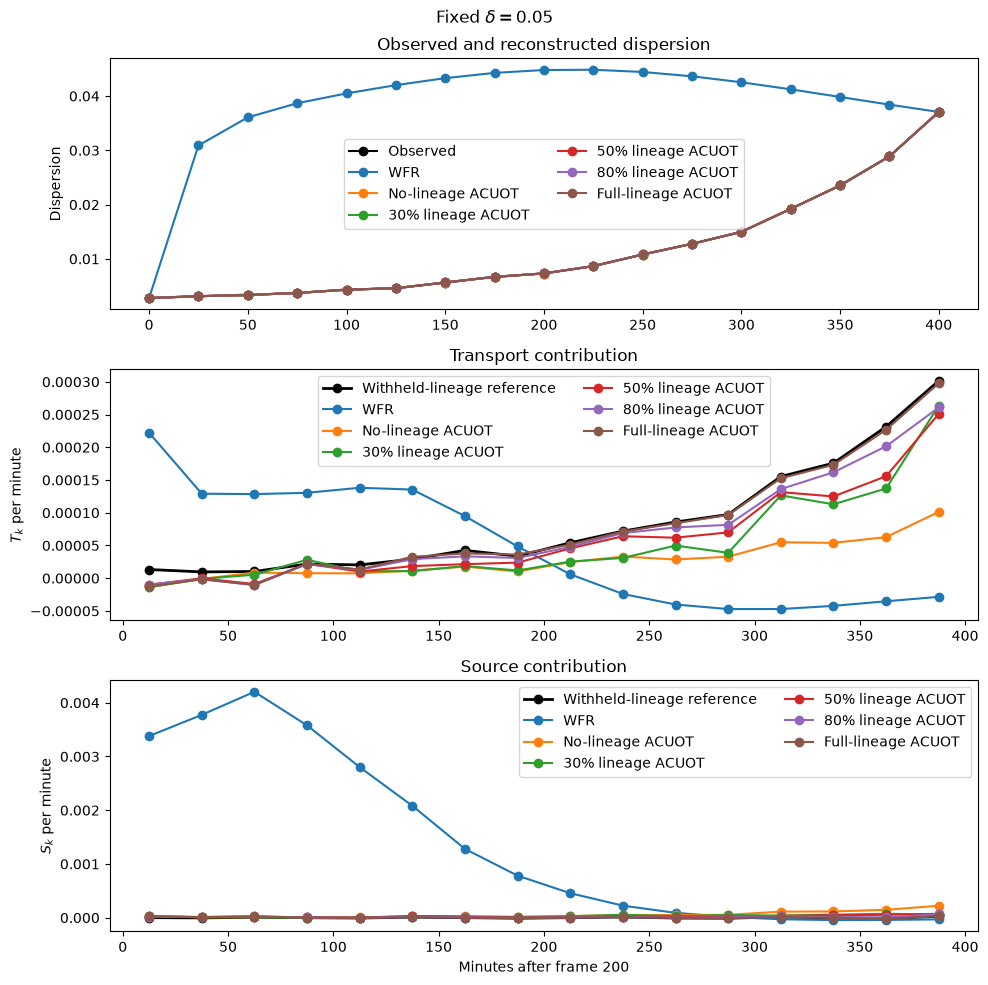

In [9]:
if globals().get("RESULTS_DELTA") != DELTA:
    raise RuntimeError("Run the fixed-delta WFR and ACUOT cells first.")

def anchored_decomposition(solution):
    momentum_y = np.asarray(solution.V.D[1])
    momentum_x = np.asarray(solution.V.D[2])
    source = np.asarray(solution.V.Z)
    transport = (
        (
            2.0
            * (Y[None, :, :] - mu_y_mid[:, None, None])
            / N_mid[:, None, None]
            * momentum_y
            + 2.0
            * (X[None, :, :] - mu_x_mid[:, None, None])
            / N_mid[:, None, None]
            * momentum_x
        ).sum(axis=(1, 2))
        * CELL_AREA
    )
    source_contribution = (
        (source_kernel * source).sum(axis=(1, 2)) * CELL_AREA
    )
    return transport, source_contribution


def density_dispersion_at_nodes(solution):
    mass, first_y, first_x, raw_second = raw_moments(solution.U.D[0])
    return raw_second / mass - (first_y / mass) ** 2 - (first_x / mass) ** 2


def constraint_values(solution, blocks):
    centered_fields = solution.V.D + [solution.V.Z]
    values = []
    for block in blocks:
        value = sum(
            (kernel * field).sum(axis=(1, 2))
            for kernel, field in zip(block, centered_fields)
        ) * CELL_AREA
        values.append(np.asarray(value))
    return values


def normalized_block_violations(solution, blocks, lower, upper):
    values = constraint_values(solution, blocks)
    block_violations = []
    for value, lo, hi in zip(values, lower, upper):
        violation = np.maximum(np.maximum(lo - value, value - hi), 0.0)
        scale = np.maximum(1.0, np.maximum(np.abs(lo), np.abs(hi)))
        block_violations.append(float(np.max(violation / scale)))
    return block_violations


def endpoint_l2(solution):
    errors = [
        np.sqrt(((solution.U.D[0][0] - observed_density[0]) ** 2).sum() * CELL_AREA),
        np.sqrt(((solution.U.D[0][-1] - observed_density[-1]) ** 2).sum() * CELL_AREA),
    ]
    return float(max(errors))


def normalized_node_moment_error(solution):
    predicted = raw_moments(solution.U.D[0])
    observed = (N_node, P_y_node, P_x_node, R_node)
    errors = [
        np.max(np.abs(value - target) / np.maximum(1.0, np.abs(target)))
        for value, target in zip(predicted, observed)
    ]
    return float(max(errors))


def rmse(values):
    values = np.asarray(values)
    return float(np.sqrt(np.mean(values**2)))


def mae(values):
    return float(np.mean(np.abs(values)))


dO_dt = np.diff(O_node) / DT
T_reference = dO_dt - source_full

decompositions = {}
summary_rows = []
for name, (solution, history, blocks, lower, upper) in method_data.items():
    transport, source = anchored_decomposition(solution)
    decompositions[name] = (transport, source)
    l2_loss, relative_l2 = trajectory_l2(solution)
    block_violations = (
        None
        if lower is None
        else normalized_block_violations(solution, blocks, lower, upper)
    )
    summary_rows.append(
        {
            "method": name,
            "density_L2": l2_loss,
            "relative_density_L2": relative_l2,
            "T_MAE": mae(transport - T_reference),
            "T_RMSE": rmse(transport - T_reference),
            "S_MAE": mae(source - source_full),
            "S_RMSE": rmse(source - source_full),
            "closure_RMSE": rmse(transport + source - dO_dt),
            "final_CE_L2": float(np.sqrt(max(solution.dist_from_CE(), 0))),
            "iter_CE_L2": float(np.sqrt(max(history[1][-1], 0))),
            "iter_interp_L2": float(np.sqrt(max(history[2][-1], 0))),
            "endpoint_L2_max": endpoint_l2(solution),
            "node_moment_error": normalized_node_moment_error(solution),
            "moment_violation": (
                np.nan if block_violations is None else max(block_violations[:4])
            ),
            "source_violation": (
                np.nan
                if block_violations is None or len(block_violations) < 5
                else block_violations[4]
            ),
            "minimum_density": float(np.min(solution.U.D[0])),
        }
    )


coverage_rows = []
for percentage, interval in lineage_intervals.items():
    if percentage == 0:
        continue
    coverage_rows.append(
        {
            "lineage_pct": percentage,
            "coverage": float(
                np.mean(
                    (source_full >= interval["lower"])
                    & (source_full <= interval["upper"])
                )
            ),
            "events_revealed": int(interval["revealed_counts"].sum()),
            "events_total": int(division_counts.sum()),
        }
    )
print("Configured lineage-interval coverage:")
print_table(coverage_rows)

node_time = (node_frames - FRAME_START) * FRAME_DT_MINUTES
mid_time = 0.5 * (node_time[:-1] + node_time[1:])

print(f"\nResults for delta={DELTA:g}")
print_table(summary_rows)
print(
    f"delta={DELTA:g}: full-lineage source-observable max error: "
    f"{np.max(np.abs(decompositions['Full-lineage ACUOT'][1] - source_full)):.3e}"
)
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

axes[0].plot(node_time, O_node, "k-o", label="Observed")
for name, (solution, _, _, _, _) in method_data.items():
    axes[0].plot(node_time, density_dispersion_at_nodes(solution), "o-", label=name)
axes[0].set_ylabel("Dispersion")
axes[0].set_title("Observed and reconstructed dispersion")
axes[0].legend(ncol=2)

axes[1].plot(mid_time, T_reference, "k-o", linewidth=2, label="Withheld-lineage reference")
for name, (transport, _) in decompositions.items():
    axes[1].plot(mid_time, transport, "o-", label=name)
axes[1].set_ylabel(r"$T_k$ per minute")
axes[1].set_title("Transport contribution")
axes[1].legend(ncol=2)

axes[2].plot(mid_time, source_full, "k-o", linewidth=2, label="Withheld-lineage reference")
for name, (_, source) in decompositions.items():
    axes[2].plot(mid_time, source, "o-", label=name)
axes[2].set_xlabel(f"Minutes after frame {FRAME_START}")
axes[2].set_ylabel(r"$S_k$ per minute")
axes[2].set_title("Source contribution")
axes[2].legend(ncol=2)

fig.suptitle(fr"Fixed $\delta={DELTA:g}$")
fig.tight_layout()
plt.show()
plt.close(fig)

## Paper figure: dispersion contributions

The two main panels show each ACUOT contribution minus its withheld-lineage reference at $\delta=0.05$, with WFR in optional insets. Set `PAPER_SHOW_WFR_INSETS=True` to enable insets. Each inset searches for empty space and keeps its decorated footprint inside the parent axes.

The PDF canvas is exactly `TEXTWIDTH_PT = 370.38374` TeX pt wide and fits within `TEXTHEIGHT_PT = 598.0` TeX pt. The manuscript page is `PAPERWIDTH_PT = 614.295` by `PAPERHEIGHT_PT = 794.96999` TeX pt. Figures are sized for inclusion in the text block, using 72.27 TeX pt/inch (PDF points use 72/inch). Exports are not cropped, so the physical width is preserved. Set `PAPER_FIGURE_PATH=None` to disable this export.


(a) Transport contribution: WFR inset placed at lower left.
(b) Source contribution: WFR inset placed at upper left.
Saved paper figure to C:\Users\mao17\Workspace\acuot\paper\figures\020-toiam-dispersion-contributions_delta-0.05.pdf
Paper figure canvas: 5.125 x 2.4 inches (370.38374 TeX pt wide).


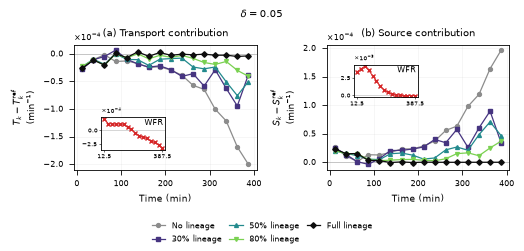

In [10]:
# Experimental compact figure sized to the LaTeX text width.
PAPER_FIGURE_WIDTH_IN = FIGURE_WIDTH_IN
PAPER_FIGURE_HEIGHT_IN = 2.4
PAPER_SHOW_WFR_INSETS = True
PAPER_FIGURE_PATH = (
    REPO_ROOT
    / "paper"
    / "figures"
    / "020-toiam-dispersion-contributions_delta-0.05.pdf"
)

partial_percentages = [
    percentage
    for percentage in LINEAGE_PERCENTAGES
    if percentage not in (0, 100)
]
partial_names = [
    f"{percentage:g}% lineage ACUOT"
    for percentage in partial_percentages
]
paper_method_names = [
    "No-lineage ACUOT",
    *partial_names,
    "Full-lineage ACUOT",
]
paper_labels = {
    "No-lineage ACUOT": "No lineage",
    "Full-lineage ACUOT": "Full lineage",
    **{
        name: f"{percentage:g}% lineage"
        for name, percentage in zip(partial_names, partial_percentages)
    },
}
paper_styles = {
    "No-lineage ACUOT": {"color": "0.55", "marker": "o"},
    "Full-lineage ACUOT": {"color": "0.05", "marker": "D"},
}
if partial_names:
    partial_colors = plt.get_cmap("viridis")(
        np.linspace(0.15, 0.8, len(partial_names))
    )
    partial_markers = ["s", "^", "v", "P", "X", "<", ">"]
    for index, (name, color) in enumerate(zip(partial_names, partial_colors)):
        paper_styles[name] = {
            "color": color,
            "marker": partial_markers[index % len(partial_markers)],
        }

paper_rc = {
    "font.size": 6.5,
    "axes.titlesize": 7.5,
    "axes.labelsize": 6.5,
    "axes.linewidth": 0.6,
    "xtick.labelsize": 6.0,
    "ytick.labelsize": 6.0,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize": 6.0,
    "lines.linewidth": 0.9,
    "lines.markersize": 2.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

PAPER_INSET_WIDTH = 0.35
PAPER_INSET_HEIGHT = 0.26
# Reserve room inside the parent axes for inset tick labels and multipliers.
PAPER_INSET_EDGE_PAD_X = 0.15
PAPER_INSET_EDGE_PAD_Y = 0.16
PAPER_INSET_LEFT = PAPER_INSET_EDGE_PAD_X
PAPER_INSET_RIGHT = 1.0 - PAPER_INSET_EDGE_PAD_X - PAPER_INSET_WIDTH
PAPER_INSET_LOWER = PAPER_INSET_EDGE_PAD_Y
PAPER_INSET_UPPER = 1.0 - PAPER_INSET_EDGE_PAD_Y - PAPER_INSET_HEIGHT
PAPER_INSET_CANDIDATES = [
    # Prefer familiar corners when one is already empty.
    ("upper right", (PAPER_INSET_RIGHT, PAPER_INSET_UPPER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    ("upper left", (PAPER_INSET_LEFT, PAPER_INSET_UPPER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    ("lower right", (PAPER_INSET_RIGHT, PAPER_INSET_LOWER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    ("lower left", (PAPER_INSET_LEFT, PAPER_INSET_LOWER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    # Intermediate positions often need much less added headroom.
    ("upper center-right", (0.40, PAPER_INSET_UPPER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    ("lower center-right", (0.40, PAPER_INSET_LOWER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    ("upper center", (0.325, PAPER_INSET_UPPER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    ("lower center", (0.325, PAPER_INSET_LOWER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    ("upper center-left", (0.25, PAPER_INSET_UPPER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
    ("lower center-left", (0.25, PAPER_INSET_LOWER, PAPER_INSET_WIDTH, PAPER_INSET_HEIGHT)),
]
# Extra footprint occupied by labels: left, bottom, right, top.
PAPER_INSET_DECORATION_PAD = (0.08, 0.07, 0.04, 0.07)
PAPER_INSET_CLEARANCE = 0.025


def sampled_curve_points(x, curves, samples_per_segment=32):
    """Densely sample plotted segments so inset placement sees crossings."""
    x = np.asarray(x, dtype=float)
    fractions = np.linspace(0.0, 1.0, samples_per_segment, endpoint=False)
    sampled = []
    for curve in curves:
        y = np.asarray(curve, dtype=float)
        segment_x = (
            x[:-1, None]
            + fractions[None, :] * np.diff(x)[:, None]
        )
        segment_y = (
            y[:-1, None]
            + fractions[None, :] * np.diff(y)[:, None]
        )
        sampled.append(
            np.column_stack(
                [
                    np.append(segment_x.ravel(), x[-1]),
                    np.append(segment_y.ravel(), y[-1]),
                ]
            )
        )
    points = np.concatenate(sampled, axis=0)
    return points[np.isfinite(points).all(axis=1)]


def points_in_axes_coordinates(ax, points):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    return np.column_stack(
        [
            (points[:, 0] - xlim[0]) / (xlim[1] - xlim[0]),
            (points[:, 1] - ylim[0]) / (ylim[1] - ylim[0]),
        ]
    )


def inset_footprint(bounds):
    """Include the title, ticks, and multiplier in placement geometry."""
    x0, y0, width, height = bounds
    left, bottom, right, top = PAPER_INSET_DECORATION_PAD
    return (
        x0 - left,
        y0 - bottom,
        width + left + right,
        height + bottom + top,
    )


def inset_overlap_count(points_axes, bounds, clearance=PAPER_INSET_CLEARANCE):
    x0, y0, width, height = inset_footprint(bounds)
    inside = (
        (points_axes[:, 0] >= x0 - clearance)
        & (points_axes[:, 0] <= x0 + width + clearance)
        & (points_axes[:, 1] >= y0 - clearance)
        & (points_axes[:, 1] <= y0 + height + clearance)
    )
    return int(inside.sum())


def choose_inset_location(ax, x, curves):
    """Choose an empty corner, or minimally expand y to make one."""
    points = sampled_curve_points(x, curves)
    points_axes = points_in_axes_coordinates(ax, points)
    for location, bounds in PAPER_INSET_CANDIDATES:
        if inset_overlap_count(points_axes, bounds) == 0:
            return bounds, location, 0.0

    lower, upper = ax.get_ylim()
    current_span = upper - lower
    xlim = ax.get_xlim()
    point_x_axes = (points[:, 0] - xlim[0]) / (xlim[1] - xlim[0])
    expansion_options = []

    for order, (location, bounds) in enumerate(PAPER_INSET_CANDIDATES):
        x0, y0, width, height = inset_footprint(bounds)
        in_horizontal_band = (
            (point_x_axes >= x0 - PAPER_INSET_CLEARANCE)
            & (point_x_axes <= x0 + width + PAPER_INSET_CLEARANCE)
        )
        band_y = points[in_horizontal_band, 1]
        if y0 > 0.5:
            clear_below = y0 - PAPER_INSET_CLEARANCE
            needed_span = (band_y.max() - lower) / clear_below
            new_span = max(current_span, 1.03 * needed_span)
            new_limits = (lower, lower + new_span)
        else:
            clear_above = y0 + height + PAPER_INSET_CLEARANCE
            needed_span = (upper - band_y.min()) / (1.0 - clear_above)
            new_span = max(current_span, 1.03 * needed_span)
            new_limits = (upper - new_span, upper)
        relative_expansion = new_span / current_span - 1.0
        expansion_options.append(
            (relative_expansion, order, bounds, location, new_limits)
        )

    relative_expansion, _, bounds, location, new_limits = min(
        expansion_options
    )
    ax.set_ylim(new_limits)
    return bounds, location, relative_expansion


def inset_decorations_inside_parent(
    parent, inset, renderer, padding_points=2.0
):
    """Check decorated inset containment with a physical safety margin."""
    parent_box = parent.get_window_extent(renderer)
    inset_box = inset.get_tightbbox(renderer)
    padding = padding_points * parent.figure.dpi / 72.0
    return inset_box is not None and (
        inset_box.x0 >= parent_box.x0 + padding
        and inset_box.y0 >= parent_box.y0 + padding
        and inset_box.x1 <= parent_box.x1 - padding
        and inset_box.y1 <= parent_box.y1 - padding
    )


def plot_paper_contributions(decompositions, figure_path):
    with plt.rc_context(paper_rc):
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(PAPER_FIGURE_WIDTH_IN, PAPER_FIGURE_HEIGHT_IN),
            sharex=True,
            layout="constrained",
        )
        fig.suptitle(fr"$\delta={DELTA:g}$", fontsize=7.5)
        panel_specs = [
            (
                axes[0],
                0,
                T_reference,
                "(a) Transport contribution",
                r"$T_k-T_k^{\mathrm{ref}}$" + "\n" + r"(min$^{-1}$)",
            ),
            (
                axes[1],
                1,
                source_full,
                "(b) Source contribution",
                r"$S_k-S_k^{\mathrm{ref}}$" + "\n" + r"(min$^{-1}$)",
            ),
        ]
        paper_insets = []

        for ax, component, reference, title, ylabel in panel_specs:
            ax.axhline(0.0, color="0.75", linewidth=0.6, zorder=0)
            main_curves = [np.zeros_like(mid_time, dtype=float)]
            for name in paper_method_names:
                difference = decompositions[name][component] - reference
                main_curves.append(difference)
                ax.plot(
                    mid_time,
                    difference,
                    label=paper_labels[name],
                    **paper_styles[name],
                )
            ax.set_title(title)
            ax.set_xlabel("Time (min)")
            ax.set_ylabel(ylabel)
            ax.grid(alpha=0.18, linewidth=0.4)
            ax.ticklabel_format(
                axis="y", style="sci", scilimits=(-2, 2), useMathText=True
            )

            if PAPER_SHOW_WFR_INSETS:
                inset_bounds, inset_location, range_expansion = (
                    choose_inset_location(ax, mid_time, main_curves)
                )
                inset = ax.inset_axes(inset_bounds, zorder=5)
                inset.set_in_layout(False)
                inset.patch.set_facecolor("white")
                inset.patch.set_alpha(0.97)
                inset.axhline(0.0, color="0.75", linewidth=0.45, zorder=0)
                inset.plot(
                    mid_time,
                    decompositions["WFR"][component] - reference,
                    color="tab:red",
                    marker="x",
                    linewidth=0.7,
                    markersize=2.2,
                )
                inset.text(
                    0.97,
                    0.95,
                    "WFR",
                    transform=inset.transAxes,
                    ha="right",
                    va="top",
                    fontsize=5.5,
                    zorder=4,
                    clip_on=True,
                    bbox={
                        "facecolor": "white",
                        "edgecolor": "none",
                        "alpha": 0.85,
                        "pad": 0.15,
                    },
                )
                inset.set_xticks([mid_time[0], mid_time[-1]])
                inset.tick_params(labelsize=4.5, length=1.5, width=0.4, pad=1)
                inset.ticklabel_format(
                    axis="y", style="sci", scilimits=(0, 0), useMathText=True
                )
                inset.yaxis.get_offset_text().set_fontsize(4.5)
                paper_insets.append((ax, inset, title))
                expansion_note = (
                    ""
                    if range_expansion == 0.0
                    else f" after expanding the y range by {range_expansion:.1%}"
                )
                print(
                    f"{title}: WFR inset placed at {inset_location}"
                    f"{expansion_note}."
                )

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="outside lower center",
            ncols=min(3, len(labels)),
            frameon=False,
            handlelength=1.6,
            columnspacing=0.9,
        )

        if paper_insets:
            # Constrained layout must settle before decorated bounds are measured.
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()
            hidden_label_panels = []
            for parent, inset, panel_title in paper_insets:
                if inset_decorations_inside_parent(parent, inset, renderer):
                    continue
                # Backend/font fallback: retain the inset and internal title, but
                # suppress external labels rather than crossing the parent axes.
                inset.tick_params(labelleft=False, labelbottom=False)
                inset.yaxis.get_offset_text().set_visible(False)
                hidden_label_panels.append(panel_title)

            if hidden_label_panels:
                fig.canvas.draw()
                renderer = fig.canvas.get_renderer()
                if any(
                    not inset_decorations_inside_parent(parent, inset, renderer)
                    for parent, inset, _ in paper_insets
                ):
                    raise RuntimeError(
                        "Could not contain a WFR inset inside its parent axes."
                    )
                print(
                    "Inset tick labels hidden to preserve the parent-axis "
                    "boundary in: " + ", ".join(hidden_label_panels)
                )

        if figure_path is not None:
            figure_path.parent.mkdir(parents=True, exist_ok=True)
            # Deliberately omit bbox_inches='tight': it changes the physical width.
            save_manuscript_pdf(fig, figure_path)
            print(f"Saved paper figure to {figure_path}")
        print(
            f"Paper figure canvas: {PAPER_FIGURE_WIDTH_IN:.6g} x "
            f"{PAPER_FIGURE_HEIGHT_IN:g} inches "
            f"({TEXTWIDTH_PT:.5f} TeX pt wide)."
        )
        plt.show()
        plt.close(fig)

plot_paper_contributions(decompositions, PAPER_FIGURE_PATH)


## Source and momentum on the same microscope images

Each method panel combines the signed source heatmap `solution.V.Z[k]` and momentum arrows (`solution.V.D[2]` horizontally, `solution.V.D[1]` vertically) at $\delta=0.05$. Both fields are centered on the interval and displayed on its ending microscope frame. Positive vertical momentum points downward. These are momentum arrows; no division by density or multiplication by the interval duration is applied.

Cyan outlines mark newly appearing persistent tracking IDs. Both daughters are new tracks, while one division adds one net cell. With a frame stride greater than one, only descendants still present at the ending frame are outlined. The initial observation has no preceding interval and therefore no source/momentum panel.

Red means source creation, blue destruction, and zero is transparent. Separate source and momentum colorbars share fixed scales across every selected interval and method. Both use logarithmic colors with a linear region near zero. Arrow lengths also use a shared logarithmic scale unless `QUIVER_LOG_LENGTHS=False`. `SOURCE_COLOR_LIMIT=None` uses the maximum absolute source; set a positive limit to inspect weaker sources. `QUIVER_STRIDE` and `QUIVER_SCALE` control arrow density and size.

The reference is repeated beside groups of up to three methods. `OVERLAY_INTERVALS=None` includes every interval; for example, `[0, 3, 7]` selects the first, fourth, and eighth intervals. `OVERLAY_INTERVALS_PER_FIGURE` controls pagination and is automatically capped to fit the 598 pt text height. Every PDF is exactly 370.38374 TeX pt wide, with filenames identifying the sequence, frames, and interval indices (one-based in filenames). Set `OVERLAY_PDF_DIR=None` to show figures without exporting. Original images default to `TOIAM_ROOT / SEQUENCE`; `TOIAM_RAW_DIR` overrides this location.

The cell runs the shared `toiam_momentum_overlay.py` helper using retained solutions, without rerunning the optimizer.


Saved C:\Users\mao17\Workspace\acuot\paper\figures\021-toiam-source-momentum_delta-0.05_seq-00_frames-200-250_intervals-01-02.pdf


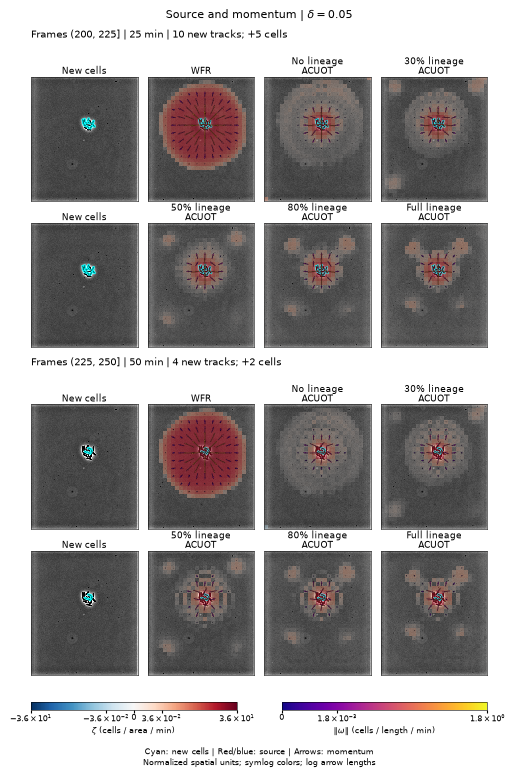

Saved C:\Users\mao17\Workspace\acuot\paper\figures\021-toiam-source-momentum_delta-0.05_seq-00_frames-250-300_intervals-03-04.pdf


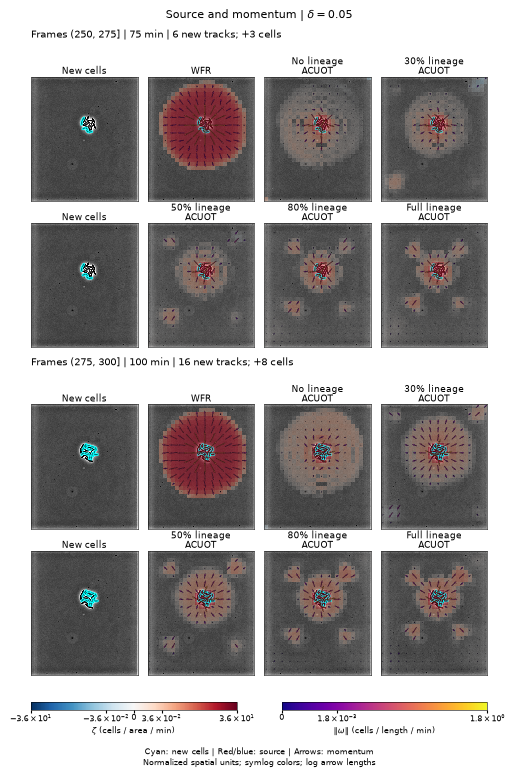

Saved C:\Users\mao17\Workspace\acuot\paper\figures\021-toiam-source-momentum_delta-0.05_seq-00_frames-300-350_intervals-05-06.pdf


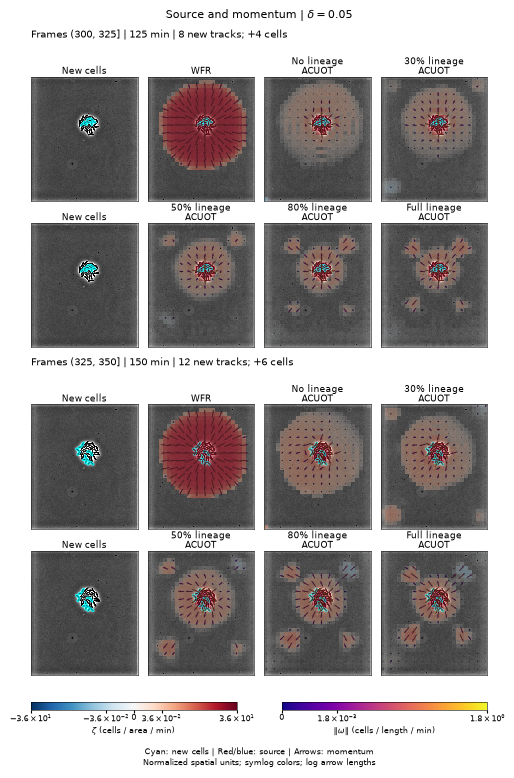

Saved C:\Users\mao17\Workspace\acuot\paper\figures\021-toiam-source-momentum_delta-0.05_seq-00_frames-350-400_intervals-07-08.pdf


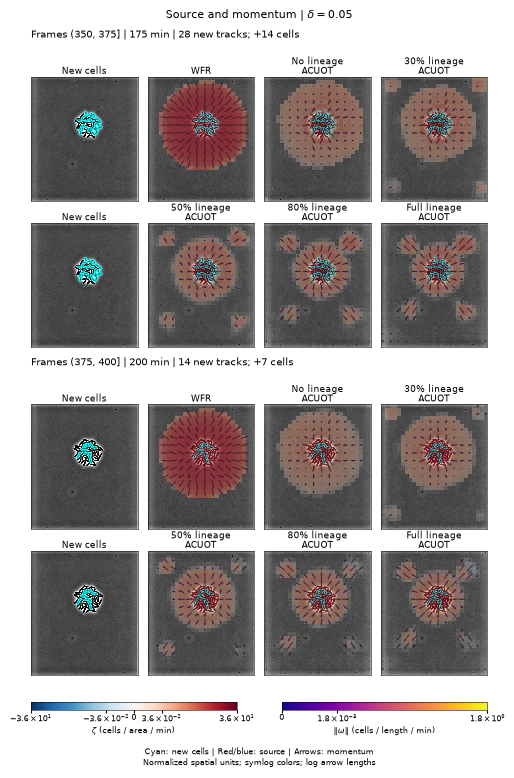

Saved C:\Users\mao17\Workspace\acuot\paper\figures\021-toiam-source-momentum_delta-0.05_seq-00_frames-400-450_intervals-09-10.pdf


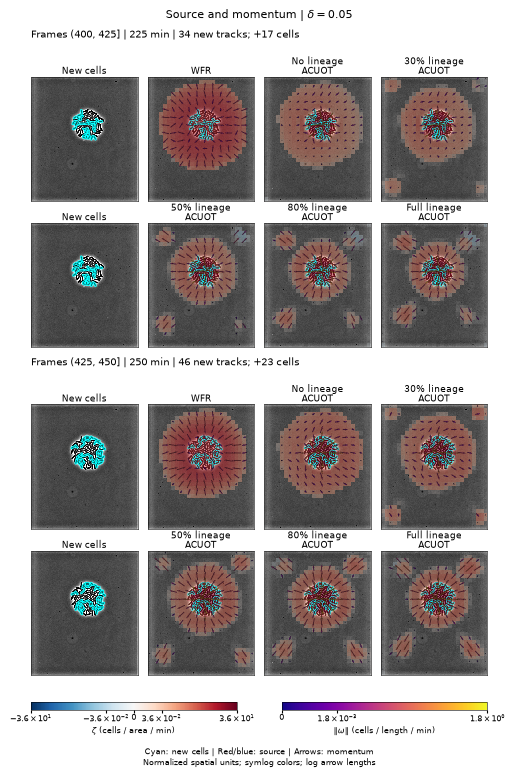

Saved C:\Users\mao17\Workspace\acuot\paper\figures\021-toiam-source-momentum_delta-0.05_seq-00_frames-450-500_intervals-11-12.pdf


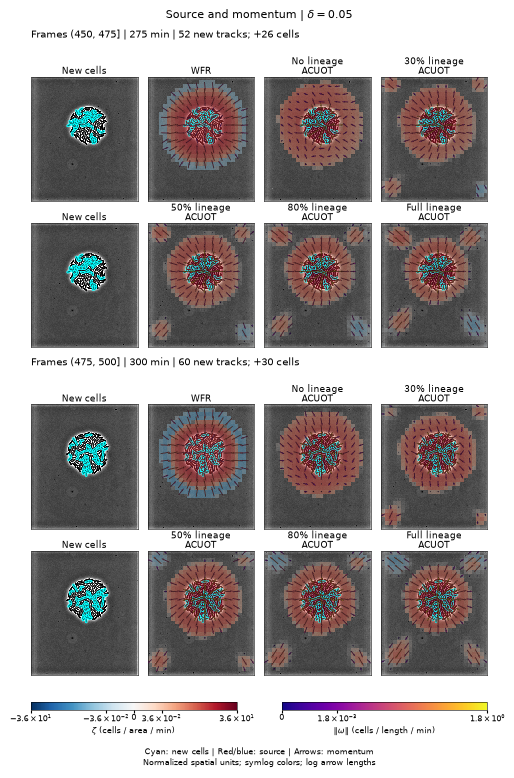

Saved C:\Users\mao17\Workspace\acuot\paper\figures\021-toiam-source-momentum_delta-0.05_seq-00_frames-500-550_intervals-13-14.pdf


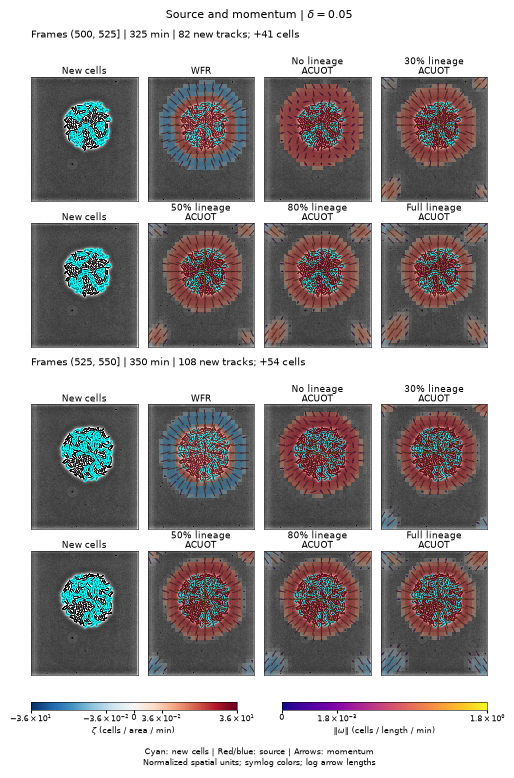

Saved C:\Users\mao17\Workspace\acuot\paper\figures\021-toiam-source-momentum_delta-0.05_seq-00_frames-550-600_intervals-15-16.pdf


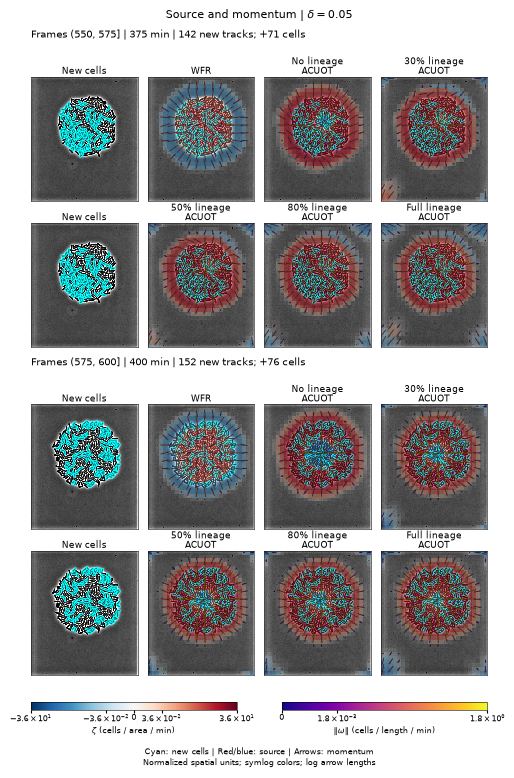

In [11]:
import runpy

OVERLAY_INTERVALS = None  # Zero-based interval indices, or None for all intervals.
OVERLAY_INTERVALS_PER_FIGURE = 2
OVERLAY_PDF_DIR = REPO_ROOT / "paper" / "figures"  # None disables PDF export.
SOURCE_COLOR_LIMIT = None
SOURCE_LINEAR_FRACTION = 0.001
SOURCE_MAX_ALPHA = 0.65
QUIVER_STRIDE = 2
QUIVER_SCALE = None
QUIVER_LOG_LENGTHS = True

_overlay_results = runpy.run_path(
    str(REPO_ROOT / "paper" / "toiam_momentum_overlay.py"),
    init_globals=globals(),
)
overlay_figure_paths = _overlay_results["overlay_figure_paths"]
del _overlay_results


## Reading the result and limitations

All methods use $\delta=0.05$. WFR is the unconstrained baseline. No-lineage ACUOT keeps the observed moment equalities but omits the source constraint block, showing what those moments alone imply for the decomposition. Each configured positive percentage adds its sampled source interval. Full-lineage ACUOT is an oracle showing what the scalar-constrained formulation can recover when all division locations are revealed.

The summary separates density fidelity, decomposition error, numerical closure, endpoint error, continuity/interpolation diagnostics, and final constraint violation. A small direct closure residual is expected from midpoint time discretization; large moment or source violations indicate inadequate PPXA convergence.

This notebook implements one sequence, one validated window, configurable lineage percentages with one shared seed, and the no-lineage/full-lineage references. It does not add all-sequence orchestration, repeated sampling trials, temporal smoothing, bootstrapping, downloads, or caches. The paper figure cell exports the dispersion contributions; the combined overlay cell exports all selected source/momentum intervals as manuscript-sized PDFs.
